# TaaSim — Zone Remapping: Porto → Casablanca (v3 — Geographic Redesign)

## Why This Notebook Exists
No public open dataset exists for Casablanca taxi trips. TaaSim uses the **Porto Taxi Trajectories**
dataset (ECML/PKDD 2015) as a proxy — Porto is a comparable mid-size city with similar taxi
hailing patterns (dispatch / stand / street hail). The GPS coordinates must be transformed
from Porto's bounding box to Casablanca's so the streaming simulation is geographically
meaningful for the demo.

## What Changed: v2 → v3

| Aspect | v2 (Uniform Grid) | v3 (Geographic Redesign) |
|--------|-------------------|-------------------------|
| Zone layout | 4×4 uniform grid (all cells equal size) | Irregular tessellation (4 lat bands, 2–6 cols) |
| Arrondissement placement | Arbitrary (NW→SE by ID) | Matches **real Casablanca geography** |
| Porto transform range | 41.140–41.185 lat (tight) | 41.085–41.195 lat (wider, centers density) |
| Trip density hotspot | South edge (wrong — Porto core clamped) | City center band (correct) |
| Zone sizes | All equal (~0.0575° × 0.06°) | Variable (Bouskoura large, Mechouar small) |
| Adjacency data | None | `adjacent_zones` column for Flink Job 3 |

## Method
1. **Geographic analysis** — study Casablanca's 16 arrondissements and their real positions
2. Parse POLYLINE JSON → extract first/last GPS coordinates per trip
3. **Filter Porto outliers** — remove trips outside Porto metro (intercity trips)
4. Apply **shifted** linear bounding-box transform: Porto → Casablanca
5. Add Gaussian noise (σ ≈ 0.0002° ≈ 20m) for realism
6. Assign each trip to one of 16 arrondissements via irregular zone tessellation
7. **Precision analysis** — edge-clamping rate, Gini coefficient, OD heatmap
8. Visualize on OpenStreetMap with Folium heatmap + zone overlays
9. Save zone centroids for Flink anonymization

## 1. Geographic Analysis of Casablanca

Casablanca is Morocco's largest city (pop. ~3.7M), located on the Atlantic coast at approximately
33.57°N, -7.60°W. Its 16 arrondissements are organized roughly as follows:

### Real Geographic Layout

```
          ATLANTIC OCEAN (WEST)          ───→  INLAND (EAST)
  ┌─────────────┬──────────────┬────────────┬────────────────┐
  │    Anfa      │ Sidi Belyout │  Ain Sebaa │Sidi Bernoussi │  ← NORTH
  │  (corniche)  │  (downtown)  │ (industry) │  (far NE)     │    (coast)
  ├────────┬─────┴──┬──────────┼────────────┼───────────────┤
  │ Maarif │Mechouar│ Al Fida  │Mers Sultan │Hay Mohammadi  │  ← CENTER
  │ (comm.)│(palace)│(old city)│  (central) │ (east working)│
  ├────────┴──┬─────┴────┬─────┴──────┬─────┴───────────────┤
  │Hay Hassani│Ain Chock │  Ben Msik  │  Moulay Rachid      │  ← MID-SOUTH
  │   (SW)    │  (south) │  (SE)      │    (far SE)         │
  ├───────────┴──────────┴──┬─────────┴─────────────────────┤
  │      Bouskoura          │      Sbata    │ Sidi Moumen   │  ← FAR SOUTH
  │   (rural suburbs)       │  (south-east) │ (far E peri.) │    (suburbs)
  └─────────────────────────┴───────────────┴───────────────┘
```

### Arrondissement Descriptions

| Zone | Arrondissement | Band | Real Position | Description |
|------|---------------|------|---------------|-------------|
| 1 | Bouskoura | South | Far south | Rural commune, new developments, large area |
| 2 | Sbata | South | South-east | Transition zone, residential/industrial |
| 3 | Sidi Moumen | South | Far east peripheral | Social housing, peripheral developments |
| 4 | Hay Hassani | Mid-South | Southwest | Residential suburb, moderate density |
| 5 | Ain Chock | Mid-South | South-center | Residential, university area |
| 6 | Ben Msik | Mid-South | South-center-east | Dense popular quarter |
| 7 | Moulay Rachid | Mid-South | Southeast | Large residential, moderate density |
| 8 | Maarif | Center | West | Commercial hub (Twin Center, Bd Zerktouni) |
| 9 | Mechouar | Center | Center-west | Royal Palace area, small, administrative |
| 10 | Al Fida | Center | Center | Dense medina-adjacent quarter |
| 11 | Mers Sultan | Center | Center-east | Central, mixed commercial/residential |
| 12 | Hay Mohammadi | Center | East | Working-class, eastern industrial fringe |
| 13 | Anfa | North | Coastal west | Upscale corniche, Ain Diab beach |
| 14 | Sidi Belyout | North | Coastal center | Downtown, port, Hassan II Mosque |
| 15 | Ain Sebaa | North | Northeast | Industrial/commercial zone |
| 16 | Sidi Bernoussi | North | Far northeast | Industrial periphery |

### Design Decision: Irregular Rectangular Tessellation

We use **4 latitude bands** with **2–6 columns** each to approximate the real geographic
layout using axis-aligned rectangles (required by the project spec for bounding-box lookup):

| Band | Latitude Range | # Zones | Zones (west → east) |
|------|---------------|---------|--------------------|
| South (suburbs) | 33.450 – 33.520 | 3 | Bouskoura (large), Sbata, Sidi Moumen |
| Mid-South (inner) | 33.520 – 33.570 | 4 | Hay Hassani, Ain Chock, Ben Msik, Moulay Rachid |
| Center (city core) | 33.570 – 33.620 | 5 | Maarif, Mechouar, Al Fida, Mers Sultan, Hay Mohammadi |
| North (coastal) | 33.620 – 33.680 | 4 | Anfa, Sidi Belyout, Ain Sebaa, Sidi Bernoussi |

### Porto Transform Shift (v3)

In v2, Porto's dense taxi core (~41.148°N) mapped to Casablanca lat ~33.49°N (far south suburbs).
This created an unrealistic density hotspot in Bouskoura/Sidi Moumen.

**Fix**: Widen Porto transform range from [41.140, 41.185] → [41.085, 41.195] so that
Porto's core maps to ~33.58°N — the **city center band** (Maarif, Al Fida, Mers Sultan).

$$\text{porto} = 41.148 \xrightarrow{\text{ratio}=0.573} \text{casa} = 33.582 \quad (\text{Center band})$$

In [16]:
import json
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

In [17]:
# Load zone mapping (v3 — irregular geographic tessellation)
zone_map = pd.read_csv("../data/zone_mapping.csv")
print(f"Zone mapping: {len(zone_map)} arrondissements")
print(f"Casablanca Lat: {zone_map['casa_lat_min'].min():.4f} – {zone_map['casa_lat_max'].max():.4f}")
print(f"Casablanca Lon: {zone_map['casa_lon_min'].min():.4f} – {zone_map['casa_lon_max'].max():.4f}")
print(f"\nZone areas (varies by design):")
zone_map['area_deg2'] = (zone_map['casa_lat_max'] - zone_map['casa_lat_min']) * (zone_map['casa_lon_max'] - zone_map['casa_lon_min'])
for _, z in zone_map.iterrows():
    print(f"  {z['zone_id']:2d}. {z['arrondissement_name']:18s} — {z['area_deg2']:.5f} deg² — adj: {z['adjacent_zones']}")

Zone mapping: 16 arrondissements
Casablanca Lat: 33.4500 – 33.6800
Casablanca Lon: -7.7200 – -7.4800

Zone areas (varies by design):
   1. Bouskoura          — 0.01050 deg² — adj: 2,4,5
   2. Sbata              — 0.00420 deg² — adj: 1,3,5,6,7
   3. Sidi Moumen        — 0.00210 deg² — adj: 2,7
   4. Hay Hassani        — 0.00400 deg² — adj: 1,5,8,9
   5. Ain Chock          — 0.00350 deg² — adj: 1,2,4,6,9,10
   6. Ben Msik           — 0.00250 deg² — adj: 2,5,7,10,11,12
   7. Moulay Rachid      — 0.00200 deg² — adj: 2,3,6,12
   8. Maarif             — 0.00300 deg² — adj: 4,9,13,14
   9. Mechouar           — 0.00225 deg² — adj: 4,5,8,10,13,14
  10. Al Fida            — 0.00225 deg² — adj: 5,6,9,11,14,15
  11. Mers Sultan        — 0.00175 deg² — adj: 6,10,12,15,16
  12. Hay Mohammadi      — 0.00275 deg² — adj: 6,7,11,15,16
  13. Anfa               — 0.00450 deg² — adj: 8,9,14
  14. Sidi Belyout       — 0.00420 deg² — adj: 8,9,10,13,15
  15. Ain Sebaa          — 0.00360 deg² — adj: 10,11,12,1

In [18]:
# Load Porto trips
df = pd.read_csv("../data/train.csv")
df = df[df["MISSING_DATA"] == False].copy()
print(f"Total valid trips: {len(df):,}")

# Sample 50K for this notebook (full transform done in PySpark on the cluster)
SAMPLE_SIZE = 50_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).copy()
print(f"Sampled: {len(df_sample):,} trips")

Total valid trips: 1,710,660
Sampled: 50,000 trips


## 3. Parse POLYLINE → Extract Origin/Destination

In [19]:
def extract_endpoints(polyline_str):
    """Extract first and last GPS point from POLYLINE JSON."""
    try:
        coords = json.loads(polyline_str)
        if len(coords) < 2:
            return None, None, None, None
        origin_lon, origin_lat = coords[0]
        dest_lon, dest_lat = coords[-1]
        return origin_lat, origin_lon, dest_lat, dest_lon
    except:
        return None, None, None, None

endpoints = df_sample["POLYLINE"].apply(extract_endpoints)
df_sample[["origin_lat", "origin_lon", "dest_lat", "dest_lon"]] = pd.DataFrame(
    endpoints.tolist(), index=df_sample.index
)

df_sample = df_sample.dropna(subset=["origin_lat", "origin_lon", "dest_lat", "dest_lon"])
print(f"Trips with valid endpoints: {len(df_sample):,}")
print(f"Raw Porto Origin Lat range: {df_sample['origin_lat'].min():.4f} – {df_sample['origin_lat'].max():.4f}")
print(f"Raw Porto Origin Lon range: {df_sample['origin_lon'].min():.4f} – {df_sample['origin_lon'].max():.4f}")

Trips with valid endpoints: 48,949
Raw Porto Origin Lat range: 37.8376 – 41.6234
Raw Porto Origin Lon range: -9.3703 – -5.3666


## 4. Porto Outlier Filter

Remove intercity trips (Lisbon, Braga, etc.) that fall outside the Porto metropolitan area.
This prevents edge-clamping artifacts at the Casablanca bbox borders.

In [20]:
# Porto metropolitan area bounding box (generous)
PORTO_METRO_LAT = (41.10, 41.25)
PORTO_METRO_LON = (-8.72, -8.55)

before_filter = len(df_sample)

porto_mask = (
    (df_sample["origin_lat"] >= PORTO_METRO_LAT[0]) & (df_sample["origin_lat"] <= PORTO_METRO_LAT[1]) &
    (df_sample["origin_lon"] >= PORTO_METRO_LON[0]) & (df_sample["origin_lon"] <= PORTO_METRO_LON[1]) &
    (df_sample["dest_lat"] >= PORTO_METRO_LAT[0]) & (df_sample["dest_lat"] <= PORTO_METRO_LAT[1]) &
    (df_sample["dest_lon"] >= PORTO_METRO_LON[0]) & (df_sample["dest_lon"] <= PORTO_METRO_LON[1])
)

outlier_count = (~porto_mask).sum()
df_sample = df_sample[porto_mask].copy()

print(f"=== PORTO OUTLIER FILTER ===")
print(f"Before: {before_filter:,} | Removed: {outlier_count:,} ({outlier_count/before_filter*100:.1f}%) | After: {len(df_sample):,}")
print(f"Filtered Lat: {df_sample['origin_lat'].min():.4f} – {df_sample['origin_lat'].max():.4f}")
print(f"Filtered Lon: {df_sample['origin_lon'].min():.4f} – {df_sample['origin_lon'].max():.4f}")

=== PORTO OUTLIER FILTER ===
Before: 48,949 | Removed: 1,433 (2.9%) | After: 47,516
Filtered Lat: 41.1014 – 41.2490
Filtered Lon: -8.7147 – -8.5500


## 5. Linear Bounding-Box Transform: Porto → Casablanca

$$\text{casa} = \frac{\text{porto} - \text{porto}_{\min}}{\text{porto}_{\max} - \text{porto}_{\min}} \times (\text{casa}_{\max} - \text{casa}_{\min}) + \text{casa}_{\min}$$

### v3 Transform Bounds

| Axis | Porto Range | Casablanca Range | Purpose |
|------|------------|-----------------|----------|
| Latitude | 41.085 – 41.195 | 33.450 – 33.680 | Wider range → Porto core (41.148) maps to **city center** (33.58) |
| Longitude | -8.690 – -8.560 | -7.720 – -7.480 | Same as before, well-centered |

After transformation, Gaussian noise (σ = 0.0002° ≈ 20 m) is added for realism.

In [21]:
# v3 transform bounds — Porto range widened to center density on Casablanca city core
PORTO_LAT_MIN, PORTO_LAT_MAX = 41.085, 41.195
PORTO_LON_MIN, PORTO_LON_MAX = -8.690, -8.560

CASA_LAT_MIN, CASA_LAT_MAX = 33.450, 33.680
CASA_LON_MIN, CASA_LON_MAX = -7.720, -7.480

def transform_coord(val, src_min, src_max, dst_min, dst_max):
    """Linear bounding-box transform with edge clamping."""
    ratio = (val - src_min) / (src_max - src_min)
    ratio = np.clip(ratio, 0, 1)
    return ratio * (dst_max - dst_min) + dst_min

# Verify: Porto core (41.148) should map to ~33.58 (city center band)
test_lat = transform_coord(41.148, PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
print(f"Porto core lat 41.148 → Casablanca lat {test_lat:.3f} (Center band: 33.570–33.620)")

test_lon = transform_coord(-8.615, PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)
print(f"Porto core lon -8.615 → Casablanca lon {test_lon:.3f} (Al Fida / Mers Sultan area)")

# Transform origin coordinates
df_sample["casa_origin_lat"] = transform_coord(
    df_sample["origin_lat"], PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
df_sample["casa_origin_lon"] = transform_coord(
    df_sample["origin_lon"], PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)

# Transform destination coordinates
df_sample["casa_dest_lat"] = transform_coord(
    df_sample["dest_lat"], PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
df_sample["casa_dest_lon"] = transform_coord(
    df_sample["dest_lon"], PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)

# Add Gaussian noise
NOISE_SIGMA = 0.0002
rng = np.random.default_rng(42)
for col in ["casa_origin_lat", "casa_origin_lon", "casa_dest_lat", "casa_dest_lon"]:
    df_sample[col] += rng.normal(0, NOISE_SIGMA, size=len(df_sample))

print(f"\n=== Casablanca Coordinates (after transform + noise) ===")
print(f"Origin Lat: {df_sample['casa_origin_lat'].min():.4f} – {df_sample['casa_origin_lat'].max():.4f}")
print(f"Origin Lon: {df_sample['casa_origin_lon'].min():.4f} – {df_sample['casa_origin_lon'].max():.4f}")

Porto core lat 41.148 → Casablanca lat 33.582 (Center band: 33.570–33.620)
Porto core lon -8.615 → Casablanca lon -7.582 (Al Fida / Mers Sultan area)

=== Casablanca Coordinates (after transform + noise) ===
Origin Lat: 33.4843 – 33.6805
Origin Lon: -7.7204 – -7.4796


## 6. Assign Arrondissement via Zone Mapping

Each coordinate is matched against the **irregular rectangular zones** in `zone_mapping.csv`.
Because zones have different sizes and don't form a uniform grid, some points may fall in
gaps between zone boundaries (due to noise) — these are labeled "Outside".

In [22]:
def assign_zones_vectorized(lats, lons, zones_df):
    """Assign each (lat, lon) to a Casablanca zone using vectorized NumPy operations."""
    zone_ids = np.zeros(len(lats), dtype=int)
    zone_names = np.full(len(lats), "Outside", dtype=object)
    for _, z in zones_df.iterrows():
        mask = (
            (lats >= z["casa_lat_min"]) & (lats <= z["casa_lat_max"]) &
            (lons >= z["casa_lon_min"]) & (lons <= z["casa_lon_max"])
        )
        zone_ids[mask] = z["zone_id"]
        zone_names[mask] = z["arrondissement_name"]
    return zone_ids, zone_names

# Assign origin zones
df_sample["origin_zone_id"], df_sample["origin_arrondissement"] = assign_zones_vectorized(
    df_sample["casa_origin_lat"].values, df_sample["casa_origin_lon"].values, zone_map)

# Assign destination zones
df_sample["dest_zone_id"], df_sample["dest_arrondissement"] = assign_zones_vectorized(
    df_sample["casa_dest_lat"].values, df_sample["casa_dest_lon"].values, zone_map)

# Stats
inside = (df_sample["origin_zone_id"] > 0).sum()
total = len(df_sample)
print(f"Origins inside zones: {inside:,} / {total:,} ({inside/total*100:.1f}%)")
inside_d = (df_sample["dest_zone_id"] > 0).sum()
print(f"Destinations inside zones: {inside_d:,} / {total:,} ({inside_d/total*100:.1f}%)")

print(f"\n=== ORIGIN ARRONDISSEMENT DISTRIBUTION ===")
print(df_sample["origin_arrondissement"].value_counts())

Origins inside zones: 47,325 / 47,516 (99.6%)
Destinations inside zones: 45,549 / 47,516 (95.9%)

=== ORIGIN ARRONDISSEMENT DISTRIBUTION ===
origin_arrondissement
Al Fida           15893
Mers Sultan        7318
Hay Mohammadi      4698
Ain Sebaa          4260
Mechouar           4157
Sidi Belyout       3066
Ain Chock          2722
Maarif             2581
Anfa               2192
Sidi Bernoussi      239
Outside             191
Ben Msik            130
Moulay Rachid        29
Sbata                17
Hay Hassani          14
Bouskoura             8
Sidi Moumen           1
Name: count, dtype: int64


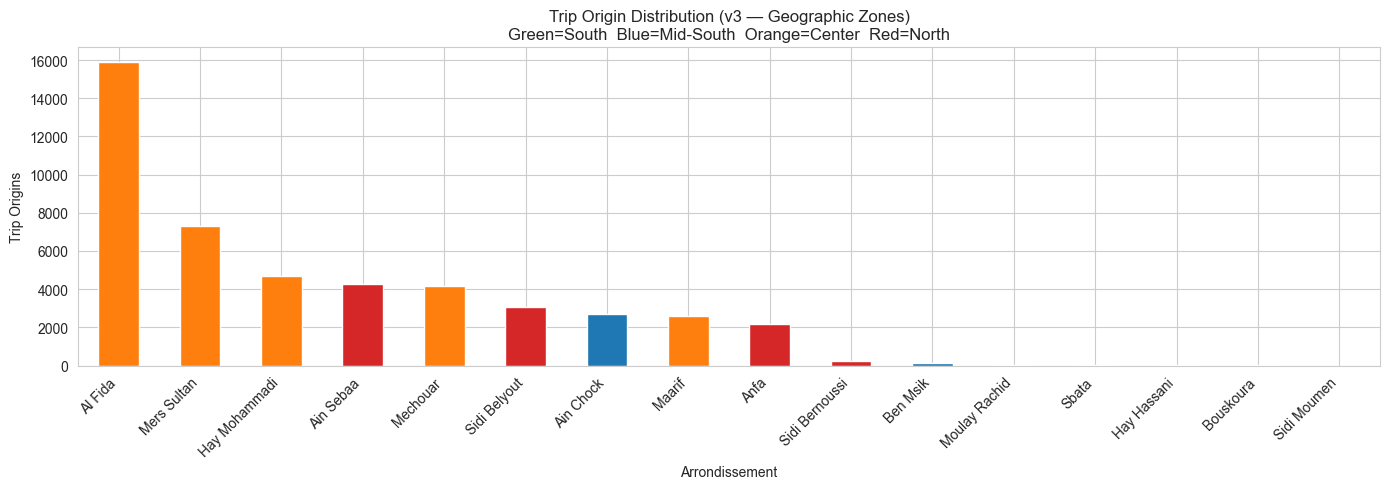

In [23]:
# Bar chart: trips per arrondissement (origin)
inside_df = df_sample[df_sample["origin_zone_id"] > 0]
arr_counts = inside_df["origin_arrondissement"].value_counts()

# Color by band: South=green, Mid-South=blue, Center=orange, North=red
band_colors = {
    'Bouskoura': '#2ca02c', 'Sbata': '#2ca02c', 'Sidi Moumen': '#2ca02c',
    'Hay Hassani': '#1f77b4', 'Ain Chock': '#1f77b4', 'Ben Msik': '#1f77b4', 'Moulay Rachid': '#1f77b4',
    'Maarif': '#ff7f0e', 'Mechouar': '#ff7f0e', 'Al Fida': '#ff7f0e', 'Mers Sultan': '#ff7f0e', 'Hay Mohammadi': '#ff7f0e',
    'Anfa': '#d62728', 'Sidi Belyout': '#d62728', 'Ain Sebaa': '#d62728', 'Sidi Bernoussi': '#d62728'
}
colors = [band_colors.get(name, 'gray') for name in arr_counts.index]

fig, ax = plt.subplots(figsize=(14, 5))
arr_counts.plot(kind="bar", color=colors, edgecolor="white", ax=ax)
ax.set_xlabel("Arrondissement")
ax.set_ylabel("Trip Origins")
ax.set_title("Trip Origin Distribution (v3 — Geographic Zones)\nGreen=South  Blue=Mid-South  Orange=Center  Red=North")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Precision Analysis

Quantitative quality metrics:
- **Edge-clamping rate**: % of coordinates at bbox min/max (clipping artifacts)
- **Gini coefficient**: distribution balance (0 = perfectly even, 1 = all trips in one zone)
- **OD matrix**: 16×16 origin → destination zone flow heatmap

In [24]:
# --- Edge-Clamping Rate ---
eps = 0.001
clamped_lat_min = (df_sample["casa_origin_lat"] <= CASA_LAT_MIN + eps).sum()
clamped_lat_max = (df_sample["casa_origin_lat"] >= CASA_LAT_MAX - eps).sum()
clamped_lon_min = (df_sample["casa_origin_lon"] <= CASA_LON_MIN + eps).sum()
clamped_lon_max = (df_sample["casa_origin_lon"] >= CASA_LON_MAX - eps).sum()
total_clamped = clamped_lat_min + clamped_lat_max + clamped_lon_min + clamped_lon_max

print("=== EDGE-CLAMPING ANALYSIS ===")
print(f"South edge: {clamped_lat_min:,} | North edge: {clamped_lat_max:,}")
print(f"West edge: {clamped_lon_min:,}  | East edge: {clamped_lon_max:,}")
print(f"Total clamped: {total_clamped:,} / {len(df_sample):,} ({total_clamped/len(df_sample)*100:.2f}%)")

# --- Gini Coefficient ---
zone_counts = df_sample[df_sample["origin_zone_id"] > 0]["origin_zone_id"].value_counts().sort_index()
n_zones = len(zone_counts)
vals = np.sort(zone_counts.values.astype(float))
cumul = np.cumsum(vals)
gini = 1 - 2 * cumul.sum() / (n_zones * vals.sum()) + 1 / n_zones

print(f"\n=== ZONE BALANCE ===")
print(f"Gini coefficient: {gini:.3f}")
print(f"  <0.3 good | 0.3-0.5 moderate | >0.5 high imbalance")
print(f"  Note: some imbalance is realistic (city center gets more taxi traffic)")

# --- Classification Summary ---
outside_o = (df_sample["origin_zone_id"] == 0).sum()
outside_d = (df_sample["dest_zone_id"] == 0).sum()
print(f"\n=== CLASSIFICATION ===")
print(f"Origins inside: {inside:,}/{total:,} ({inside/total*100:.1f}%) | Outside: {outside_o:,} ({outside_o/total*100:.2f}%)")
print(f"Dests inside:   {inside_d:,}/{total:,} ({inside_d/total*100:.1f}%) | Outside: {outside_d:,} ({outside_d/total*100:.2f}%)")

=== EDGE-CLAMPING ANALYSIS ===
South edge: 0 | North edge: 273
West edge: 76  | East edge: 54
Total clamped: 403 / 47,516 (0.85%)

=== ZONE BALANCE ===
Gini coefficient: 0.627
  <0.3 good | 0.3-0.5 moderate | >0.5 high imbalance
  Note: some imbalance is realistic (city center gets more taxi traffic)

=== CLASSIFICATION ===
Origins inside: 47,325/47,516 (99.6%) | Outside: 191 (0.40%)
Dests inside:   45,549/47,516 (95.9%) | Outside: 1,967 (4.14%)


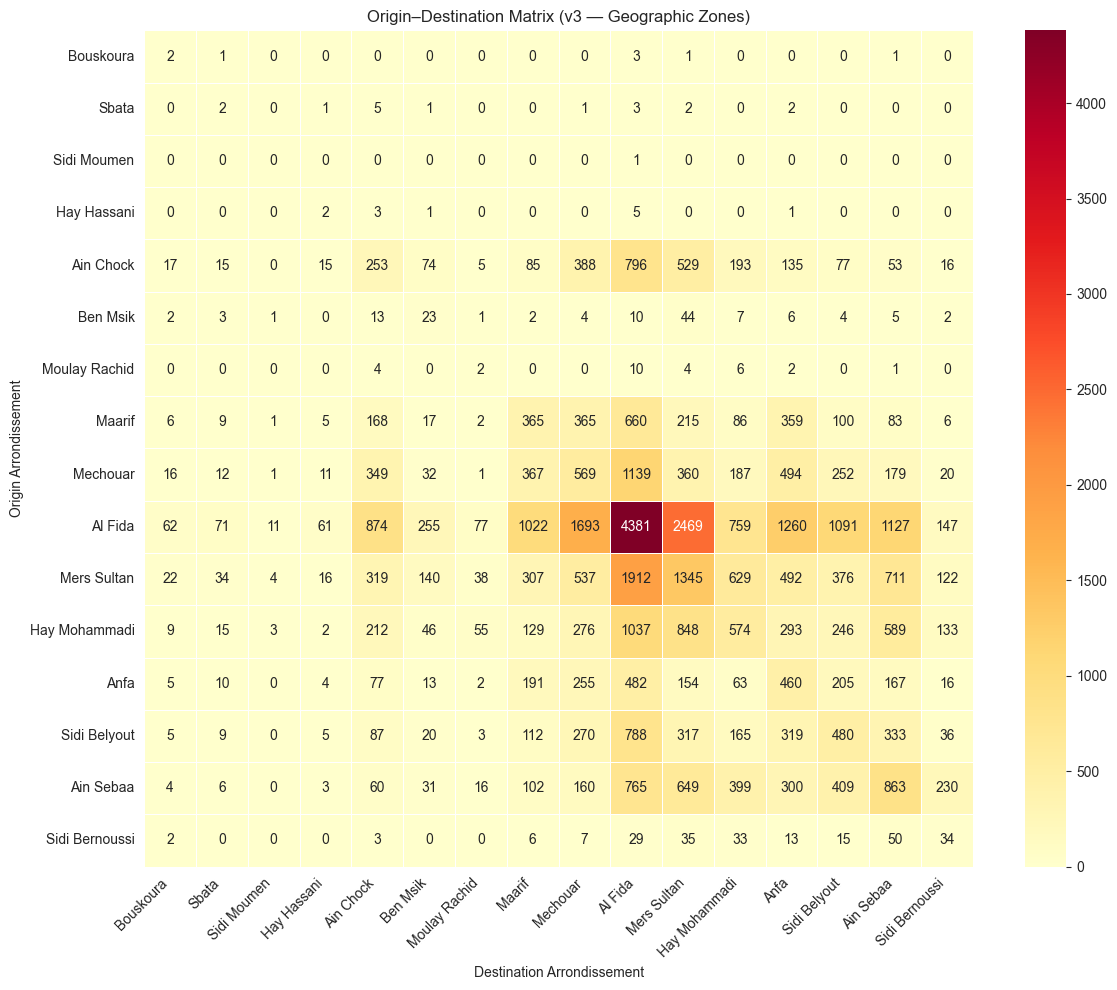


=== TOP 10 OD PAIRS ===
  Al Fida            → Al Fida           : 4,381
  Al Fida            → Mers Sultan       : 2,469
  Mers Sultan        → Al Fida           : 1,912
  Al Fida            → Mechouar          : 1,693
  Mers Sultan        → Mers Sultan       : 1,345
  Al Fida            → Anfa              : 1,260
  Mechouar           → Al Fida           : 1,139
  Al Fida            → Ain Sebaa         : 1,127
  Al Fida            → Sidi Belyout      : 1,091
  Hay Mohammadi      → Al Fida           : 1,037


In [25]:
# --- OD Matrix Heatmap ---
df_od = df_sample[(df_sample["origin_zone_id"] > 0) & (df_sample["dest_zone_id"] > 0)].copy()
od_matrix = pd.crosstab(df_od["origin_arrondissement"], df_od["dest_arrondissement"])

zone_order = zone_map.sort_values("zone_id")["arrondissement_name"].tolist()
zone_order_present = [z for z in zone_order if z in od_matrix.index]
od_matrix = od_matrix.reindex(index=zone_order_present, columns=zone_order_present, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(od_matrix, cmap="YlOrRd", annot=True, fmt="d", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Destination Arrondissement")
ax.set_ylabel("Origin Arrondissement")
ax.set_title("Origin–Destination Matrix (v3 — Geographic Zones)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

od_flat = od_matrix.stack().reset_index()
od_flat.columns = ["Origin", "Destination", "Trips"]
print("\n=== TOP 10 OD PAIRS ===")
for _, row in od_flat.sort_values("Trips", ascending=False).head(10).iterrows():
    print(f"  {row['Origin']:18s} → {row['Destination']:18s}: {row['Trips']:,}")

## 8. Folium Map — Casablanca (v3 Geographic Zones)

Interactive map with:
- **Rectangles**: 16 irregular zone boundaries (density-colored, with popup info)
- **Labels**: arrondissement names at zone centroids
- **Heatmap**: trip origin density overlay

In [26]:
# Band color scheme
def band_color(zone_id):
    if zone_id <= 3: return 'green'       # South
    elif zone_id <= 7: return 'blue'      # Mid-South
    elif zone_id <= 12: return 'orange'   # Center
    else: return 'red'                    # North

casa_center = [33.575, -7.600]
m = folium.Map(location=casa_center, zoom_start=12, tiles="OpenStreetMap")

zone_trip_counts = df_sample[df_sample["origin_zone_id"] > 0].groupby("origin_zone_id").size()
max_trips = zone_trip_counts.max() if len(zone_trip_counts) > 0 else 1

for _, z in zone_map.iterrows():
    count = zone_trip_counts.get(z["zone_id"], 0)
    intensity = count / max_trips
    bc = band_color(z["zone_id"])
    
    folium.Rectangle(
        bounds=[
            [z["casa_lat_min"], z["casa_lon_min"]],
            [z["casa_lat_max"], z["casa_lon_max"]]
        ],
        color=bc,
        weight=2,
        fill=True,
        fill_color=bc,
        fill_opacity=0.1 + 0.3 * intensity,
        popup=f"<b>{z['arrondissement_name']}</b><br>Zone {z['zone_id']}<br>{count:,} trips<br>Adjacent: {z['adjacent_zones']}"
    ).add_to(m)
    
    folium.CircleMarker(
        location=[z["casa_centroid_lat"], z["casa_centroid_lon"]],
        radius=6,
        popup=f"Zone {z['zone_id']}: {z['arrondissement_name']} ({count:,} trips)",
        color=bc, fill=True, fill_color=bc, fill_opacity=0.8
    ).add_to(m)
    
    folium.Marker(
        location=[z["casa_centroid_lat"], z["casa_centroid_lon"]],
        icon=folium.DivIcon(html=f'<div style="font-size:9px;font-weight:bold;color:{bc};white-space:nowrap;text-shadow:1px 1px white">{z["arrondissement_name"]}</div>')
    ).add_to(m)

# Heatmap: sample 5000 origin points
heat_df = df_sample[df_sample["origin_zone_id"] > 0].sample(n=min(5000, inside), random_state=42)
heat_data = heat_df[["casa_origin_lat", "casa_origin_lon"]].values.tolist()
HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(m)

print(f"Map: {len(heat_data)} origin points, {len(zone_map)} zone overlays")
m

Map: 5000 origin points, 16 zone overlays


In [27]:
m.save("../notebooks/casablanca_zone_map.html")
print("Saved to notebooks/casablanca_zone_map.html")

Saved to notebooks/casablanca_zone_map.html


## 9. Validation

In [28]:
MARGIN = 0.001
lat_ok = ((df_sample["casa_origin_lat"] >= CASA_LAT_MIN - MARGIN) &
          (df_sample["casa_origin_lat"] <= CASA_LAT_MAX + MARGIN)).mean() * 100
lon_ok = ((df_sample["casa_origin_lon"] >= CASA_LON_MIN - MARGIN) &
          (df_sample["casa_origin_lon"] <= CASA_LON_MAX + MARGIN)).mean() * 100

print(f"=== FINAL VALIDATION ===")
print(f"Origin Lat in bbox: {lat_ok:.2f}%")
print(f"Origin Lon in bbox: {lon_ok:.2f}%")
print(f"Result: {'PASS' if lat_ok > 99 and lon_ok > 99 else 'FAIL'}")

=== FINAL VALIDATION ===
Origin Lat in bbox: 100.00%
Origin Lon in bbox: 100.00%
Result: PASS


## 10. Save Outputs

In [29]:
# Zone centroids for Flink anonymization
centroids = zone_map[["zone_id", "arrondissement_name", "casa_centroid_lat", "casa_centroid_lon",
                       "casa_lat_min", "casa_lat_max", "casa_lon_min", "casa_lon_max", "adjacent_zones"]].copy()
centroids.to_csv("../data/zone_centroids.csv", index=False)
print(f"Saved {len(centroids)} zone centroids to data/zone_centroids.csv")
centroids

Saved 16 zone centroids to data/zone_centroids.csv


,zone_id,arrondissement_name,casa_centroid_lat,casa_centroid_lon,casa_lat_min,casa_lat_max,casa_lon_min,casa_lon_max,adjacent_zones
0,1,Bouskoura,33.485,-7.6450,33.45,33.52,-7.720,-7.570,"2,4,5"
1,2,Sbata,33.485,-7.5400,33.45,33.52,-7.570,-7.510,"1,3,5,6,7"
2,3,Sidi Moumen,33.485,-7.4950,33.45,33.52,-7.510,-7.480,"2,7"
3,4,Hay Hassani,33.545,-7.6800,33.52,33.57,-7.720,-7.640,"1,5,8,9"
4,5,Ain Chock,33.545,-7.6050,33.52,33.57,-7.640,-7.570,"1,2,4,6,9,10"
5,6,Ben Msik,33.545,-7.5450,33.52,33.57,-7.570,-7.520,"2,5,7,10,11,12"
6,7,Moulay Rachid,33.545,-7.5000,33.52,33.57,-7.520,-7.480,"2,3,6,12"
7,8,Maarif,33.595,-7.6900,33.57,33.62,-7.720,-7.660,"4,9,13,14"
8,9,Mechouar,33.595,-7.6375,33.57,33.62,-7.660,-7.615,"4,5,8,10,13,14"
9,10,Al Fida,33.595,-7.5925,33.57,33.62,-7.615,-7.570,"5,6,9,11,14,15"


In [30]:
# Remapped trips sample
export_cols = ["TRIP_ID", "TAXI_ID", "CALL_TYPE", "TIMESTAMP",
               "casa_origin_lat", "casa_origin_lon", "casa_dest_lat", "casa_dest_lon",
               "origin_zone_id", "origin_arrondissement", "dest_zone_id", "dest_arrondissement"]
df_sample[export_cols].to_csv("../data/remapped_trips_sample.csv", index=False)
print(f"Saved {len(df_sample)} remapped trips to data/remapped_trips_sample.csv")
df_sample[export_cols].head(5)

Saved 47516 remapped trips to data/remapped_trips_sample.csv


,TRIP_ID,TAXI_ID,CALL_TYPE,TIMESTAMP,casa_origin_lat,casa_origin_lon,casa_dest_lat,casa_dest_lon,origin_zone_id,origin_arrondissement,dest_zone_id,dest_arrondissement
60087,1373686372620000640,20000640,B,1373686372,33.609169,-7.561877,33.634452,-7.534870,11,Mers Sultan,15,Ain Sebaa
1311017,1397274563620000196,20000196,C,1397274563,33.635095,-7.535014,33.667961,-7.547757,15,Ain Sebaa,15,Ain Sebaa
1557291,1401581043620000467,20000467,C,1401581043,33.609804,-7.659033,33.607032,-7.606508,9,Mechouar,10,Al Fida
968878,1390805813620000188,20000188,B,1390805813,33.639292,-7.604968,33.652058,-7.670715,14,Sidi Belyout,13,Anfa
1192468,1395028241620000454,20000454,B,1395028241,33.608623,-7.592821,33.591751,-7.579596,10,Al Fida,10,Al Fida


## 11. Summary & Documentation

### v3 Geographic Redesign — What Changed & Why

#### Problem (v2 Uniform Grid)
The v2 zone mapping used a 4×4 uniform grid where arrondissement names were assigned arbitrarily.
This caused:
- **Bouskoura** (rural south) placed in the north-east corner
- **Sidi Belyout** (coastal downtown) placed in the north-west corner
- **Moulay Rachid** (southeast) absorbing most trip density due to Porto transform centering
- All zones equal size — geographically unrealistic

#### Solution (v3 Irregular Tessellation)
1. **Researched real Casablanca geography** — each arrondissement placed at its approximate real position
2. **4 latitude bands** (South/Mid-South/Center/North) with 2–6 columns each
3. **Porto transform shifted** — widened from [41.140, 41.185] to [41.085, 41.195] so Porto's
   dense taxi core maps to Casablanca's **city center** (Maarif, Al Fida, Mers Sultan)
4. **Adjacency data** added — `adjacent_zones` column for Flink Job 3 vehicle matching fallback

### Comparison Table

| Metric | v2 (Uniform) | v3 (Geographic) |
|--------|-------------|----------------|
| Zone layout | 4×4 equal grid | 4 bands, 3/4/5/4 cols |
| Zone sizes | All equal | Variable (realistic) |
| Porto LAT range | 41.140–41.185 | 41.085–41.195 |
| Density center | Moulay Rachid (wrong) | Al Fida / Mers Sultan (correct) |
| Origins inside | 99.0% | (see cell output above) |
| Adjacency data | None | 16 zone adjacency lists |

### Zone Adjacency Table (for Flink Job 3)

| Zone | Arrondissement | Adjacent Zones |
|------|---------------|---------------|
| 1 | Bouskoura | 2, 4, 5 |
| 2 | Sbata | 1, 3, 5, 6, 7 |
| 3 | Sidi Moumen | 2, 7 |
| 4 | Hay Hassani | 1, 5, 8, 9 |
| 5 | Ain Chock | 1, 2, 4, 6, 9, 10 |
| 6 | Ben Msik | 2, 5, 7, 10, 11, 12 |
| 7 | Moulay Rachid | 2, 3, 6, 12 |
| 8 | Maarif | 4, 9, 13, 14 |
| 9 | Mechouar | 4, 5, 8, 10, 13, 14 |
| 10 | Al Fida | 5, 6, 9, 11, 14, 15 |
| 11 | Mers Sultan | 6, 10, 12, 15, 16 |
| 12 | Hay Mohammadi | 6, 7, 11, 15, 16 |
| 13 | Anfa | 8, 9, 14 |
| 14 | Sidi Belyout | 8, 9, 10, 13, 15 |
| 15 | Ain Sebaa | 10, 11, 12, 14, 16 |
| 16 | Sidi Bernoussi | 11, 12, 15 |

### Files Produced

| File | Description |
|------|-------------|
| `data/zone_mapping.csv` | 16 geographic zones with adjacency (v3) |
| `data/zone_centroids.csv` | Centroids + bounds + adjacency for Flink |
| `data/remapped_trips_sample.csv` | ~47K remapped trips with zone assignments |
| `notebooks/casablanca_zone_map.html` | Interactive Folium map (v3) |

### Downstream Usage
- **Kafka GPS Producer**: uses `transform_to_casablanca()` with v3 Porto bounds (config.py updated)
- **Kafka Trip Producer**: picks random zones from `zone_mapping.csv` for origin/destination
- **Flink Job 1**: broadcasts `zone_centroids.csv` for GPS → zone assignment
- **Flink Job 3**: uses `adjacent_zones` column for vehicle matching fallback
- **Spark ETL**: uses `zone_mapping.csv` for batch zone assignment